# pass@k Run Analysis

Loads `samples.csv` and `pass_at_k.csv` from the latest run under `results/runs`.

In [8]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

run = Path("results/runs/smoke_no_delay_qwen8b")
if not run.exists():
    run = Path("../results/runs/smoke_no_delay_qwen8b")

run = run.resolve()
assert run.exists(), f"Run directory not found: {run}"

pass_at_k_csv = run / "pass_at_k.csv"
samples_csv = run / "samples.csv"
summary_json = run / "summary.json"

assert pass_at_k_csv.exists(), f"Missing pass@k CSV: {pass_at_k_csv}"
assert samples_csv.exists(), f"Missing samples CSV: {samples_csv}"
assert summary_json.exists(), f"Missing summary JSON: {summary_json}"

run

WindowsPath('C:/Users/Cash Bowman/OneDrive/Documents/UCLA Math Research/computational-algebra-llm/results/runs/smoke_no_delay_qwen8b')

In [9]:
samples = pd.read_csv(run / 'samples.csv')
pass_at_k = pd.read_csv(run / 'pass_at_k.csv')
metric_cols = [c for c in pass_at_k.columns if c.startswith('pass@')]

aggregate = pass_at_k[pass_at_k['question_id'] == '__aggregate__'].set_index('model')
aggregate[metric_cols + ['num_samples', 'num_correct']].sort_values(metric_cols[0], ascending=False)

,pass@1,pass@2,num_samples,num_correct
model,,,,
tinker/Qwen/Qwen3-8B,0.25,0.3393,112,28


In [14]:
import re
import pandas as pd
import plotly.express as px

pass_df = pd.read_csv(pass_at_k_csv)

agg = pass_df[pass_df["question_id"] == "__aggregate__"].copy()

long = agg.melt(
    id_vars=["model"],
    value_vars=[c for c in agg.columns if c.startswith("pass@")],
    var_name="metric",
    value_name="pass@k",
)

long["k"] = long["metric"].str.extract(r"pass@(\d+)").astype(int)
long = long.sort_values(["model", "k"])

fig = px.line(
    long,
    x="k",
    y="pass@k",
    color="model",
    line_dash="model",
    markers=True,
    title="Pass@k by Model",
    labels={"k": "k", "pass@k": "pass@k", "model": "Model"},
)

fig.update_traces(line_shape="spline")
fig.update_layout(
    template="plotly_white",
    xaxis=dict(dtick=1),
    yaxis=dict(range=[0, 1]),
    legend_title_text="Model",
)

fig.show()


In [11]:
by_question = pass_at_k[pass_at_k['question_id'] != '__aggregate__'].copy()
by_question.head()

,model,question_id,num_samples,num_correct,num_attempted_samples,num_reference_failed_samples,pass@1,pass@2
0,tinker/Qwen/Qwen3-8B,m2_001,2,0,2,0,0.0,0.0
1,tinker/Qwen/Qwen3-8B,m2_002,2,1,2,0,0.5,1.0
2,tinker/Qwen/Qwen3-8B,m2_003,2,0,2,0,0.0,0.0
3,tinker/Qwen/Qwen3-8B,m2_007,2,1,2,0,0.5,1.0
4,tinker/Qwen/Qwen3-8B,m2_008,2,0,2,0,0.0,0.0


,pass@1,pass@2
question_id,,
m2_001,0.0,0.0
m2_040,0.0,0.0
m2_041,0.0,0.0
m2_042,0.0,0.0
m2_044,0.0,0.0
m2_045,0.0,0.0
m2_046,0.0,0.0
m2_047,0.0,0.0
m2_048,0.0,0.0


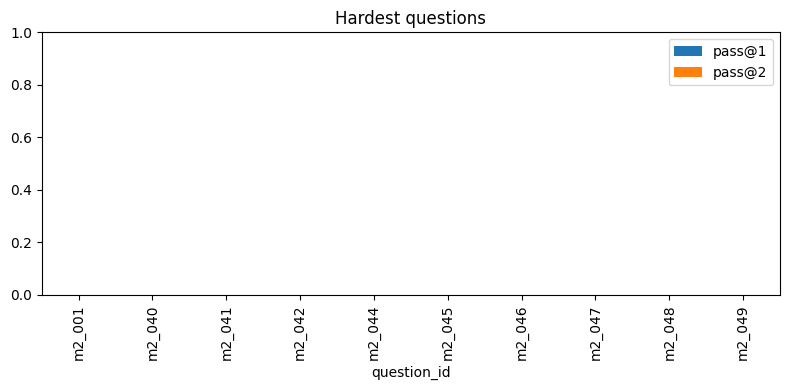

In [12]:
hardest = by_question.groupby('question_id')[metric_cols].mean().sort_values(metric_cols[0]).head(10)
display(hardest)
hardest.plot(kind='bar', figsize=(8, 4), ylim=(0, 1), title='Hardest questions')
plt.tight_layout()

In [13]:
sample_stats = samples.groupby('model').agg(
    samples=('correct', 'size'),
    correct=('correct', 'sum'),
    errors=('error', lambda s: s.notna().sum()),
    avg_total_tokens=('total_tokens', 'mean'),
)
sample_stats['accuracy'] = sample_stats['correct'] / sample_stats['samples']
sample_stats.sort_values('accuracy', ascending=False)

,samples,correct,errors,avg_total_tokens,accuracy
model,,,,,
tinker/Qwen/Qwen3-8B,156,28,0,1173.858974,0.179487
